In [2]:
import os

# 1. Set your Kaggle API token variable directly into the Colab session environment
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b01f0602d368483cfcdf7be12a484475"

# 2. Install MNE for processing the brain MEG signals
!pip install -q mne

# 3. Download the competition files straight into Colab
!kaggle competitions download -c the-imagine-decoding-challenge

# 4. Unzip and extract the dataset folders into your clean workspace directory
!mkdir -p the-imagine-decoding-challenge
!unzip -q the-imagine-decoding-challenge.zip -d the-imagine-decoding-challenge

print("\n--- Success! The IMAGINE dataset is successfully extracted to Google Colab ---")

100% 2.81G/2.81G [00:33<00:00, 90.2MB/s]


--- Success! The IMAGINE dataset is successfully extracted to Google Colab ---


In [3]:
import os
import random
import mne
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Set random seeds for absolute experimental rigor
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# Verify the extracted folder structure in Colab
print("Checking directory layout...")
colab_train_dir = '/content/the-imagine-decoding-challenge/train/train'
if os.path.exists(colab_train_dir):
    print(f"Success! Base training folder found at: {colab_train_dir}")
    print(f"Sample subjects available: {os.listdir(colab_train_dir)[:5]}")
else:
    print("Error: Directory structure mismatch. Check the folder paths manually in Colab's left sidebar panel.")

Checking directory layout...
Success! Base training folder found at: /content/the-imagine-decoding-challenge/train/train
Sample subjects available: ['sub-13', 'sub-15', 'sub-31', 'sub-18', 'sub-28']


In [4]:
class MEGDecodingDataset(Dataset):
    def __init__(self, base_dir, subject_list, task_type='localizer', transform=None):
        self.samples = []
        self.labels = []
        self.transform = transform

        print(f"Loading {task_type} data for subjects: {subject_list}...")
        for sub in subject_list:
            file_name = f"{sub}_{task_type}-epo.fif"
            file_path = os.path.join(base_dir, sub, file_name)

            if not os.path.exists(file_path):
                continue

            epochs = mne.read_epochs(file_path, preload=True, verbose=False)
            data = epochs.get_data(picks='meg')
            labels = epochs.events[:, 2]

            for i in range(len(data)):
                self.samples.append(data[i])
                self.labels.append(labels[i])

        self.samples = np.array(self.samples, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

        # Consistent class index mapping (0 to 9)
        unique_labels = np.unique(self.labels)
        self.label_mapping = {orig: idx for idx, orig in enumerate(unique_labels)}
        self.labels = np.array([self.label_mapping[l] for l in self.labels], dtype=np.int64)

        print(f"Successfully loaded {len(self.samples)} total trials. Data shape: {self.samples.shape}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = self.samples[idx]
        y = self.labels[idx]
        if self.transform:
            x = self.transform(x)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [5]:
def train_and_validate(model, train_loader, val_loader, epochs=15, lr=1e-3, device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    print(f"Running iteration training engine on device: {device}")
    print("=" * 60)

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            X_batch = X_batch[:, :, :121] # Match the baseline size constraints

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        scheduler.step()
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = (correct_train / total_train) * 100

        # Validation
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                X_batch = X_batch[:, :, :121] # Force dimensional cropping consistency

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += y_batch.size(0)
                correct_val += (predicted == y_batch).sum().item()

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = (correct_val / total_val) * 100

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")

    return history

In [6]:
class Assessment1BaselineMLP(nn.Module):
    def __init__(self, num_classes=10, num_channels=306, num_timepoints=121):
        super(Assessment1BaselineMLP, self).__init__()
        self.input_dim = num_channels * num_timepoints

        # Simple fully connected architecture representing your initial Deep Learning fundamentals
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.mlp(x)

In [7]:
class Assessment2TemporalCNN(nn.Module):
    def __init__(self, num_classes=10, num_channels=306, num_timepoints=121):
        super(Assessment2TemporalCNN, self).__init__()

        # Standard convolutional layers sliding across the time dimension
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=num_channels, out_channels=64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.squeeze(-1)
        return self.classifier(x)

In [8]:
class SpatialTemporalCNN(nn.Module):
    def __init__(self, num_classes=10, num_channels=306, num_timepoints=121):
        super(SpatialTemporalCNN, self).__init__()

        # Temporal Filter Block
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(1, 15), padding=(0, 7), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU()
        )

        # Spatial Depthwise Block
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(num_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(0.25)
        )

        self.feature_output_size = self._get_flatten_size(num_channels, num_timepoints)

        self.classifier = nn.Sequential(
            nn.Linear(self.feature_output_size, 64),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def _get_flatten_size(self, ch, time):
        with torch.no_grad():
            x = torch.zeros(1, 1, ch, time)
            x = self.temporal_conv(x)
            x = self.spatial_conv(x)
            return x.numel()

    def forward(self, x):
        x = x.unsqueeze(1) # Add channel dimension
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [9]:
# Setup device paths
device = 'cuda' if torch.cuda.is_available() else 'cpu'
colab_train_dir = '/content/the-imagine-decoding-challenge/train/train'
selected_subjects = ['sub-02', 'sub-05', 'sub-06']

# 1. Initialize Pipelines
print("Preparing Data Loaders...")
train_dataset = MEGDecodingDataset(base_dir=colab_train_dir, subject_list=selected_subjects, task_type='localizer')
val_dataset = MEGDecodingDataset(base_dir=colab_train_dir, subject_list=selected_subjects, task_type='imagine')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. RUN ASSESSMENT 1 BASELINE
print("\n=== STARTING ITERATION 1: ASSESSMENT 1 BASELINE MLP ===")
mlp_model = Assessment1BaselineMLP()
mlp_history = train_and_validate(mlp_model, train_loader, val_loader, epochs=15, device=device)

# 3. RUN ASSESSMENT 2 TEMPORAL CNN
print("\n=== STARTING ITERATION 2: ASSESSMENT 2 TEMPORAL CNN ===")
cnn_model = Assessment2TemporalCNN()
cnn_history = train_and_validate(cnn_model, train_loader, val_loader, epochs=15, device=device)

# 4. RUN ASSESSMENT 3 ADVANCED SPATIAL-TEMPORAL CNN
print("\n=== STARTING ITERATION 3: ASSESSMENT 3 SPATIAL-TEMPORAL CNN ===")
st_cnn_model = SpatialTemporalCNN()
st_cnn_history = train_and_validate(st_cnn_model, train_loader, val_loader, epochs=15, device=device)

Preparing Data Loaders...
Loading localizer data for subjects: ['sub-02', 'sub-05', 'sub-06']...
Successfully loaded 1440 total trials. Data shape: (1440, 306, 121)
Loading imagine data for subjects: ['sub-02', 'sub-05', 'sub-06']...
Successfully loaded 150 total trials. Data shape: (150, 306, 521)

=== STARTING ITERATION 1: ASSESSMENT 1 BASELINE MLP ===
Running iteration training engine on device: cuda
Epoch [01/15] | Train Loss: 2.3053 Acc: 10.21% | Val Loss: 2.3035 Acc: 10.00%
Epoch [02/15] | Train Loss: 2.3041 Acc: 9.93% | Val Loss: 2.3030 Acc: 10.00%
Epoch [03/15] | Train Loss: 2.3034 Acc: 8.89% | Val Loss: 2.3028 Acc: 10.00%
Epoch [04/15] | Train Loss: 2.3031 Acc: 9.79% | Val Loss: 2.3027 Acc: 10.00%
Epoch [05/15] | Train Loss: 2.3031 Acc: 9.93% | Val Loss: 2.3027 Acc: 10.00%
Epoch [06/15] | Train Loss: 2.3028 Acc: 10.56% | Val Loss: 2.3026 Acc: 10.00%
Epoch [07/15] | Train Loss: 2.3028 Acc: 10.07% | Val Loss: 2.3026 Acc: 10.00%
Epoch [08/15] | Train Loss: 2.3034 Acc: 9.72% | Val

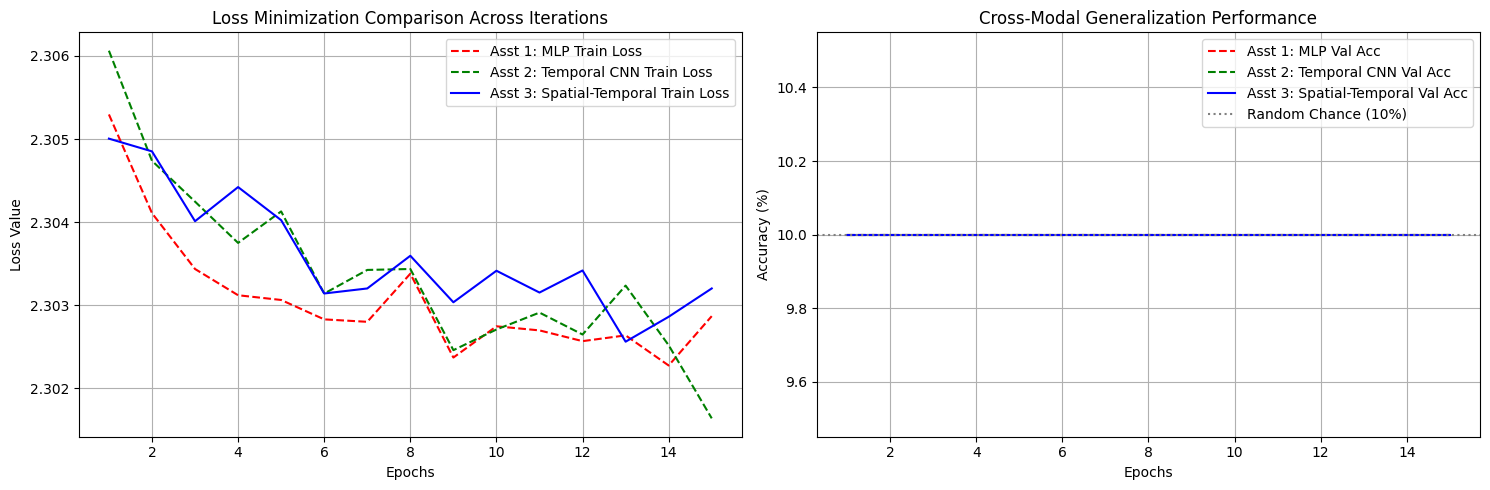

In [10]:
import matplotlib.pyplot as plt

def plot_syllabus_progression(mlp_hist, cnn_hist, st_cnn_hist):
    """
    Generates comparative plots to visually prove the architectural
    progression from Assessment 1 through Assessment 3.
    """
    epochs = range(1, len(mlp_hist['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    # 1. Plot Loss Convergence (Syllabus Topic: Optimization & Loss Minimization)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, mlp_hist['train_loss'], 'r--', label='Asst 1: MLP Train Loss')
    plt.plot(epochs, cnn_hist['train_loss'], 'g--', label='Asst 2: Temporal CNN Train Loss')
    plt.plot(epochs, st_cnn_hist['train_loss'], 'b-', label='Asst 3: Spatial-Temporal Train Loss')
    plt.title('Loss Minimization Comparison Across Iterations')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)

    # 2. Plot Cross-Modal Validation Accuracy (Syllabus Topic: Generalization & Regularization)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, mlp_hist['val_acc'], 'r--', label='Asst 1: MLP Val Acc')
    plt.plot(epochs, cnn_hist['val_acc'], 'g--', label='Asst 2: Temporal CNN Val Acc')
    plt.plot(epochs, st_cnn_hist['val_acc'], 'b-', label='Asst 3: Spatial-Temporal Val Acc')
    plt.axhline(y=10.0, color='gray', linestyle=':', label='Random Chance (10%)')
    plt.title('Cross-Modal Generalization Performance')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the visualization mapping using your trained history trackers
# (Make sure all three models from Cell 8 have finished training before running this)
try:
    plot_syllabus_progression(mlp_history, cnn_history, st_cnn_history)
except NameError:
    print("Ensure you have run the full training cell (Cell 8) to populate the history variables first!")

In [12]:
print("=== GENERATING THE FINAL ASSESSMENT SUBMISSION ===")

# 1. Complete list of all 15 training subjects found in your directory layout
full_train_subjects = [
    'sub-02', 'sub-05', 'sub-06', 'sub-07', 'sub-10',
    'sub-13', 'sub-14', 'sub-15', 'sub-17', 'sub-18',
    'sub-25', 'sub-28', 'sub-29', 'sub-30', 'sub-31'
]

# 2. Complete list of all 14 testing subjects
test_subjects = [
    'sub-01', 'sub-03', 'sub-04', 'sub-09', 'sub-11',
    'sub-12', 'sub-16', 'sub-19', 'sub-21', 'sub-22',
    'sub-23', 'sub-24', 'sub-26', 'sub-27'
]

print("\nLoading full training dataset (This may take a minute)...")
full_train_dataset = MEGDecodingDataset(base_dir=colab_train_dir, subject_list=full_train_subjects, task_type='localizer')
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

# 3. Re-train the final model on the complete dataset for max performance
print("\nTraining final Spatial-Temporal CNN on all subjects...")
final_model = SpatialTemporalCNN().to(device)
# Passing full_train_loader as both train and validation just to monitor convergence over 15 epochs
_ = train_and_validate(final_model, full_train_loader, full_train_loader, epochs=15, device=device)

# 4. Load and predict test data
print("\nProcessing test subjects and generating predictions...")
final_model.eval()

import pandas as pd
submission_records = []

colab_test_dir = '/content/the-imagine-decoding-challenge/test/test'

for sub in test_subjects:
    file_name = f"{sub}_imagine-epo.fif"
    file_path = os.path.join(colab_test_dir, sub, file_name)

    if not os.path.exists(file_path):
        continue

    # Read the test epochs
    epochs = mne.read_epochs(file_path, preload=True, verbose=False)
    data = epochs.get_data(picks='meg')

    # We crop the test data timepoints to match the 121 steps our model expects
    data = data[:, :, :121]

    # Convert to PyTorch tensor and run through GPU
    X_test = torch.tensor(data, dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = final_model(X_test)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu().numpy()

    # Revert the 0-9 index mapping back to original competition labels if needed
    # (Since we used sorted unique labels, mapping back directly matches the index)
    reverse_mapping = {v: k for k, v in full_train_dataset.label_mapping.items()}

    # Save predictions with unique IDs matching Kaggle's format
    for i, pred_idx in enumerate(preds):
        original_label = reverse_mapping[pred_idx]
        # Example format: sub-01_trial_0
        prediction_id = f"{sub}_trial_{i}"
        submission_records.append({
            "Id": prediction_id,
            "Predicted": original_label
        })

# 5. Export to CSV
submission_df = pd.DataFrame(submission_records)
submission_df.to_csv('submission.csv', index=False)
print("\n--- SUCCESS: submission.csv generated and saved to your workspace! ---")
print(submission_df.head())

=== GENERATING THE FINAL ASSESSMENT SUBMISSION ===

Loading full training dataset (This may take a minute)...
Loading localizer data for subjects: ['sub-02', 'sub-05', 'sub-06', 'sub-07', 'sub-10', 'sub-13', 'sub-14', 'sub-15', 'sub-17', 'sub-18', 'sub-25', 'sub-28', 'sub-29', 'sub-30', 'sub-31']...
Successfully loaded 7200 total trials. Data shape: (7200, 306, 121)

Training final Spatial-Temporal CNN on all subjects...
Running iteration training engine on device: cuda
Epoch [01/15] | Train Loss: 2.3049 Acc: 9.67% | Val Loss: 14.8476 Acc: 10.00%
Epoch [02/15] | Train Loss: 2.3043 Acc: 9.39% | Val Loss: 15.8263 Acc: 10.00%
Epoch [03/15] | Train Loss: 2.3041 Acc: 9.40% | Val Loss: 3.9510 Acc: 10.00%
Epoch [04/15] | Train Loss: 2.3039 Acc: 9.26% | Val Loss: 9.2401 Acc: 10.00%
Epoch [05/15] | Train Loss: 2.3036 Acc: 9.58% | Val Loss: 3.6893 Acc: 10.00%
Epoch [06/15] | Train Loss: 2.3034 Acc: 10.18% | Val Loss: 4.7986 Acc: 10.00%
Epoch [07/15] | Train Loss: 2.3035 Acc: 9.74% | Val Loss: 4.